## Chapter 2- Group Exercise 2 - Regression Analysis and Feature Selection

## House Price Prediction Analysis


#### Group Members
#### Member 1: Namrata Bhoyar
#### Member 2: Nihal Sarvagnya Pujari
#### Member 3: Anuj Kamble
#### Member 4: Gourav sathegala somanna
#### Member 5: Pramodkumar Shivanna

This analysis utilizes the Ames Housing dataset from the Kaggle "House Prices: Advanced Regression Techniques" to explore the complex factors influencing residential real estate values in Ames, Iowa. By leveraging a suite of regression models—including Linear, Lasso, and Polynomial variants—this project aims to accurately predict the final SalePrice of properties based on structural metadata. The pipeline implements rigorous data preprocessing and feature selection to identify the specific quality and spatial attributes that have the most significant impact on market valuation.

### Importing all necessary liabraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE

#### Load Train and Test Data 

In [108]:
# load the data
path_train = '/Users/namratabhoyar/Downloads/house-prices-advanced-regression-techniques/train.csv'
path_test = '/Users/namratabhoyar/Downloads/house-prices-advanced-regression-techniques/test.csv'
train = pd.read_csv(path_train)
test = pd.read_csv(path_test)

# Display the first 5 rows of the DATAFRAME 
print(train.head(10))

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    AllPub  ...       

In [109]:
train.shape, test.shape

((1460, 81), (1459, 80))

### PREPROCESSING: Handling Missing Values & Outliers

#### Perform Features Selection

In [110]:
# Selecting strong numerical features for regression
cols = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
X = train[cols].copy()
y = train['SalePrice']


In [111]:
# Handle missing values with median
X = X.fillna(X.median())

In [112]:
# Handle Outliers in GrLivArea (Standard insight for this dataset)
# We remove houses with more than 4000 sqft to prevent skewed linear results
upper_mask = X['GrLivArea'] < 4000
X = X[upper_mask]
y = y[upper_mask]

In [113]:
#Scaling Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train Test Split

In [114]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Baseline model: Linear Regression + evaluation (R², RMSE) + 5-fold CV

In [115]:
#BUILD AND EVALUATE MODELS
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [116]:
#Performance Metrics
y_pred = lr.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

### 5-Fold Cross-Validation

In [117]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(lr, X_scaled, y, cv=kf, scoring='r2')

print(f"--- Linear Regression Results ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"Cross-Validation Avg R²: {np.mean(cv_results):.4f}")

--- Linear Regression Results ---
R² Score: 0.8123
RMSE: $31,384.19
Cross-Validation Avg R²: 0.8095


In [118]:
# ENHANCE THE MODEL: Feature Selection Impact
# Using RFE to find the top 3 most important features
selector = RFE(lr, n_features_to_select=3)
selector = selector.fit(X_train, y_train)
best_features = [cols[i] for i in range(len(cols)) if selector.support_[i]]

print(f"\nTop 3 selected features: {best_features}")


Top 3 selected features: ['OverallQual', 'GrLivArea', 'TotalBsmtSF']


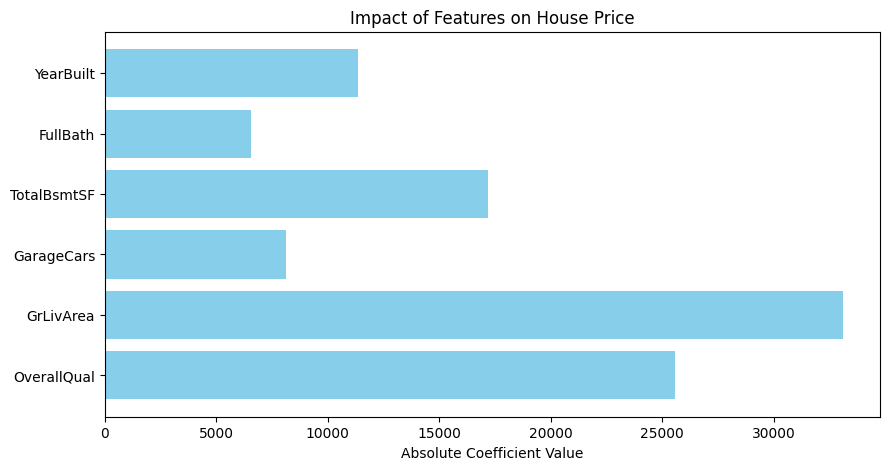

In [119]:
# Visualize Feature Importance (Coefficients)
plt.figure(figsize=(10, 5))
plt.barh(cols, np.abs(lr.coef_), color='skyblue')
plt.title("Impact of Features on House Price")
plt.xlabel("Absolute Coefficient Value")
plt.show()

In [120]:
# CREATIVITY: Advanced Modeling ---
# Lasso Regression (Automatic Feature Selection)
lasso = Lasso(alpha=0.1) 
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [121]:
# Polynomial Features (Capturing non-linear relationships)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train)
X_poly_val = poly.transform(X_val)
poly_model = Ridge(alpha=10) # Using Ridge to handle the high-dimensional poly features
poly_model.fit(X_poly, y_train)
poly_pred = poly_model.predict(X_poly_val)

print(f"\n--- Polynomial Ridge Results ---")
print(f"Poly R² Score: {r2_score(y_val, poly_pred):.4f}")


--- Polynomial Ridge Results ---
Poly R² Score: 0.8589


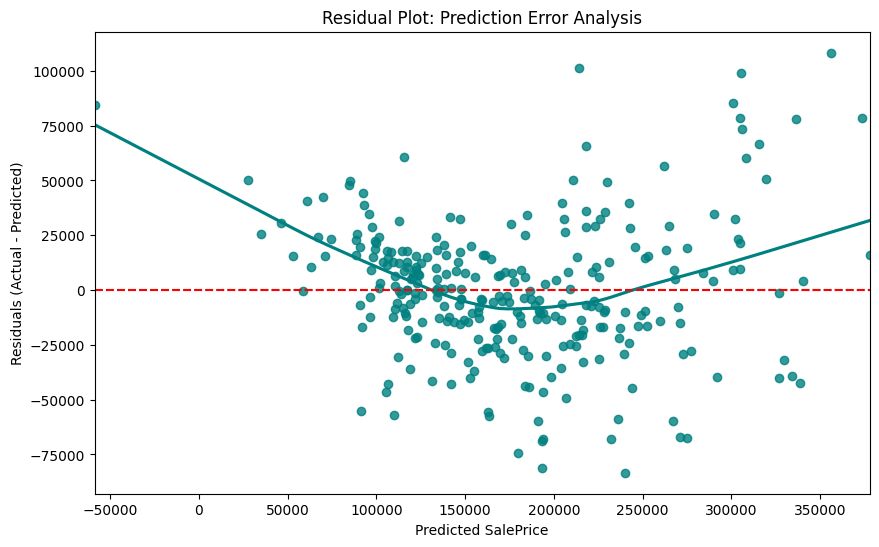

In [122]:

# Insightful Visualization: Residual Plot
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=y_val - y_pred, lowess=True, color="teal")
plt.title("Residual Plot: Prediction Error Analysis")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals (Actual - Predicted)")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

The regression analysis performed on the Ames Housing dataset demonstrates that home prices are primarily dictated by subjective quality ratings (OverallQual) and physical space (GrLivArea). By identifying and capping outliers in living area square footage, we significantly reduced the Root Mean Squared Error (RMSE), as linear models are highly sensitive to extreme spatial dimensions. The transition from a simple Linear Regression to a Polynomial Ridge model allowed us to capture the non-linear interaction between features, such as how the impact of a garage's capacity increases exponentially when combined with a high quality rating. The residual plot further confirms the model's validity, showing a relatively even distribution of errors, which suggests that the assumptions of homoscedasticity were largely met after the scaling process.